# Google Play Store: Exploratory Data Analysis

This notebook explores the Play Store export and demonstrates the labeling
and preprocessing logic used by the pipeline. **Training, tuning and final
evaluation live in `src/playstore` and run via:**

```bash
python -m playstore.train --sample-frac 0.3 --tuning-iterations 20
```

so that the exact same, tested code path produces the numbers in the README
-- nothing here is re-implemented ad hoc. See `../README.md` for the full
methodology write-up and the latest results.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from playstore import visualization as viz
from playstore.config import RAW_USECOLS
from playstore.data import load_raw_data
from playstore.target import fit_success_thresholds, make_success_label

viz.set_plot_style()
pd.set_option("display.max_columns", None)
%matplotlib inline

## 1. Load data

A few extra descriptive columns (`Rating`, `Installs`) are pulled in beyond what the model uses, purely to make the EDA plots below more informative.

In [2]:
eda_usecols = sorted(set(RAW_USECOLS) | {"Rating", "Installs"})
df = load_raw_data(usecols=eda_usecols)
print(f"Rows: {len(df):,}  Columns: {len(df.columns)}")
df.head()

Rows: 2,312,944  Columns: 13


,Category,Rating,Rating Count,Installs,Minimum Installs,Free,Price,Size,Minimum Android,Content Rating,Ad Supported,In App Purchases,Editors Choice
0,Adventure,0.0,0.0,10+,10.0,True,0.0,10M,7.1 and up,Everyone,False,False,False
1,Tools,4.4,64.0,"5,000+",5000.0,True,0.0,2.9M,5.0 and up,Everyone,True,False,False
2,Productivity,0.0,0.0,50+,50.0,True,0.0,3.7M,4.0.3 and up,Everyone,False,False,False
3,Communication,5.0,5.0,10+,10.0,True,0.0,1.8M,4.0.3 and up,Everyone,True,False,False
4,Tools,0.0,0.0,100+,100.0,True,0.0,6.2M,4.1 and up,Everyone,False,False,False


In [3]:
df.info()
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].to_frame("missing_fraction")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Category          object 
 1   Rating            float64
 2   Rating Count      float64
 3   Installs          object 
 4   Minimum Installs  float64
 5   Free              bool   
 6   Price             float64
 7   Size              object 
 8   Minimum Android   object 
 9   Content Rating    object 
 10  Ad Supported      bool   
 11  In App Purchases  bool   
 12  Editors Choice    bool   
dtypes: bool(4), float64(4), object(5)
memory usage: 167.6+ MB


,missing_fraction
Rating,0.009893
Rating Count,0.009893
Minimum Android,0.002823
Size,0.000085
Installs,0.000046
Minimum Installs,0.000046


## 2. Target variable

An app is `Success` if it has reached a high quantile of installs, a high
quantile of rating count, or has been given Editors' Choice.

**Leakage note:** the thresholds below are fit on the *entire* dataframe,
which is fine for exploring what the label looks like, but is **not** how
`playstore.train` builds it for modeling -- there, the same
`fit_success_thresholds` function is called on the training split only, and
the resulting fixed numbers are applied to the test split. Fitting them
here on all the data would leak test-set information into the label
definition if reused for training.

SuccessThresholds(installs=np.float64(10000.0), rating_count=np.float64(73.0))


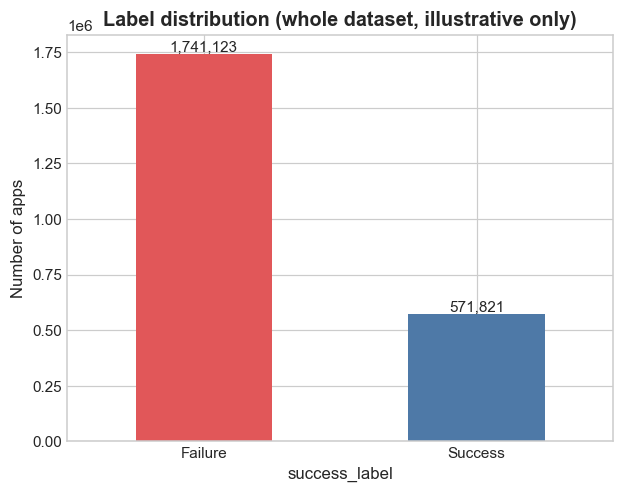

In [4]:
thresholds = fit_success_thresholds(df)
df["success_label"] = make_success_label(df, thresholds)
print(thresholds)

counts = df["success_label"].value_counts()
ax = counts.reindex(["Failure", "Success"]).plot(
    kind="bar", color=[viz.PALETTE["Failure"], viz.PALETTE["Success"]], rot=0
)
ax.set_title("Label distribution (whole dataset, illustrative only)")
ax.set_ylabel("Number of apps")
for i, v in enumerate(counts.reindex(["Failure", "Success"])):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")

## 3. Category and monetization vs. success rate

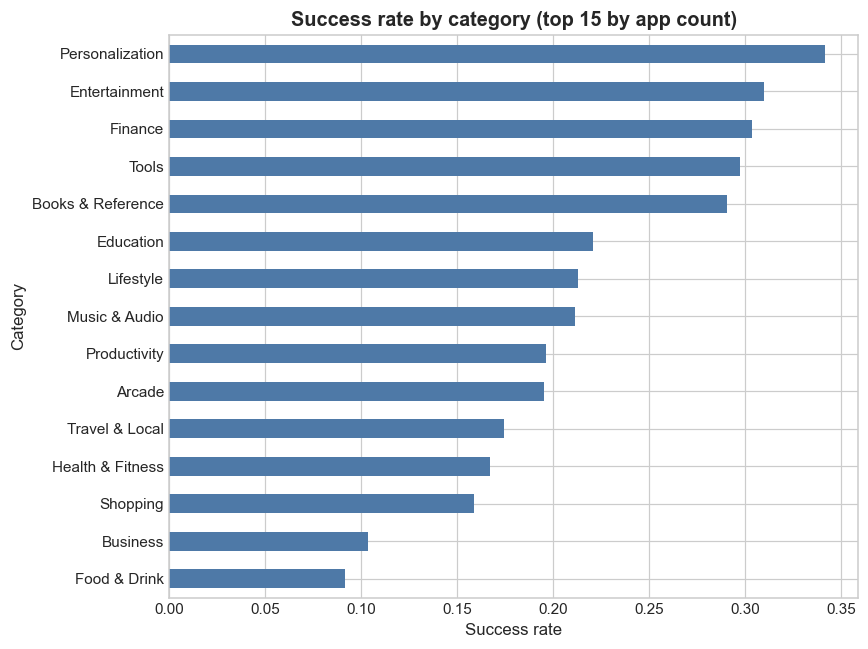

In [5]:
top_categories = df["Category"].value_counts().head(15).index
success_by_category = (
    pd.crosstab(df["Category"], df["success_label"], normalize="index")["Success"]
    .loc[top_categories]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
success_by_category.plot(kind="barh", ax=ax, color="#4e79a7")
ax.set_xlabel("Success rate")
ax.set_title("Success rate by category (top 15 by app count)")
plt.tight_layout()

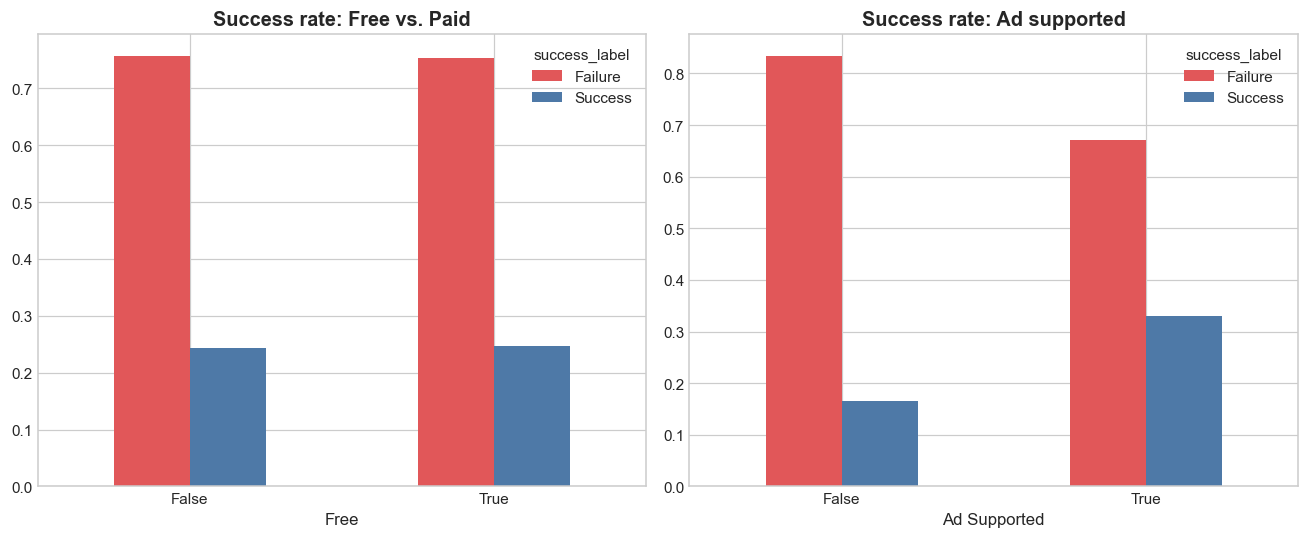

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pd.crosstab(df["Free"], df["success_label"], normalize="index").plot(
    kind="bar", ax=axes[0], color=[viz.PALETTE["Failure"], viz.PALETTE["Success"]], rot=0
)
axes[0].set_title("Success rate: Free vs. Paid")

pd.crosstab(df["Ad Supported"], df["success_label"], normalize="index").plot(
    kind="bar", ax=axes[1], color=[viz.PALETTE["Failure"], viz.PALETTE["Success"]], rot=0
)
axes[1].set_title("Success rate: Ad supported")
plt.tight_layout()

## 4. Modeling demo

This is a **small, fast** run (a subsample and a short hyperparameter
search) purely so the notebook executes in well under a minute. The
headline numbers reported in the README come from a full run with more
data and a larger search budget -- rerun the CLI command at the top of this
notebook to reproduce those.

2026-08-01 21:46:35,420 [INFO] Loading raw data from C:\Users\Rida\Documents\ml_project\play-store-success-prediction\data\raw\Google-Playstore.csv


2026-08-01 21:46:49,375 [INFO] Loaded 2312944 rows, 11 columns


2026-08-01 21:46:49,512 [INFO] Subsampled to 23129 rows (frac=0.010)


2026-08-01 21:46:49,518 [INFO] Train rows: 18503 | Test rows: 4626


2026-08-01 21:46:49,522 [INFO] Success thresholds (fit on train): SuccessThresholds(installs=np.float64(10000.0), rating_count=np.float64(75.0))


...

2026-08-01 21:47:30,642 [INFO] Chosen decision threshold (from train OOF): 0.48


2026-08-01 21:47:30,853 [INFO] Test metrics @0.50: {'threshold': 0.5, 'accuracy': 0.6294855166450497, 'precision': 0.359545239223117, 'recall': 0.6770740410347904, 'f1': 0.46967821782178215, 'roc_auc': np.float64(0.7072792658887966)}


2026-08-01 21:47:30,854 [INFO] Test metrics @0.48: {'threshold': 0.4800000000000001, 'accuracy': 0.6197578901859058, 'precision': 0.35526315789473684, 'recall': 0.6984834968777877, 'f1': 0.47097744360902255, 'roc_auc': np.float64(0.7072792658887966)}


2026-08-01 21:47:35,394 [INFO] Artifacts written to C:\Users\Rida\Documents\ml_project\play-store-success-prediction\artifacts\demo


Best model: random_forest
Chosen threshold: 0.4800000000000001
Test metrics @ chosen threshold: {'threshold': 0.4800000000000001, 'accuracy': 0.6197578901859058, 'precision': 0.35526315789473684, 'recall': 0.6984834968777877, 'f1': 0.47097744360902255, 'roc_auc': np.float64(0.7072792658887966)}


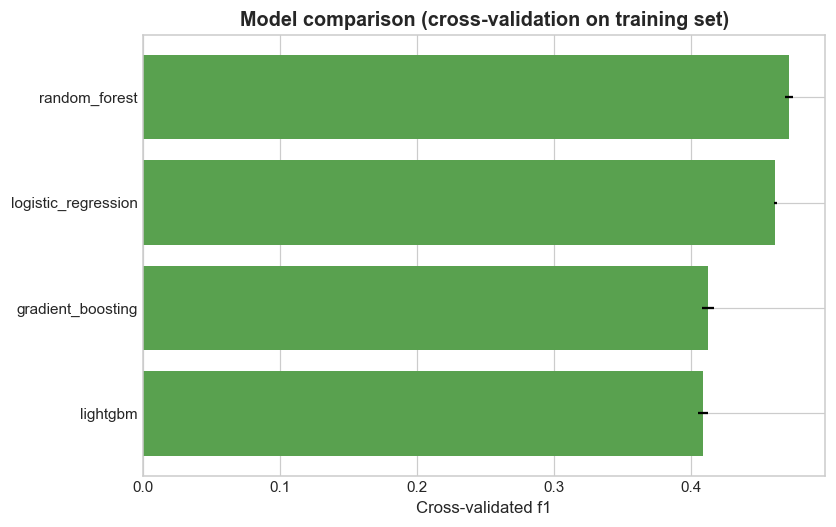

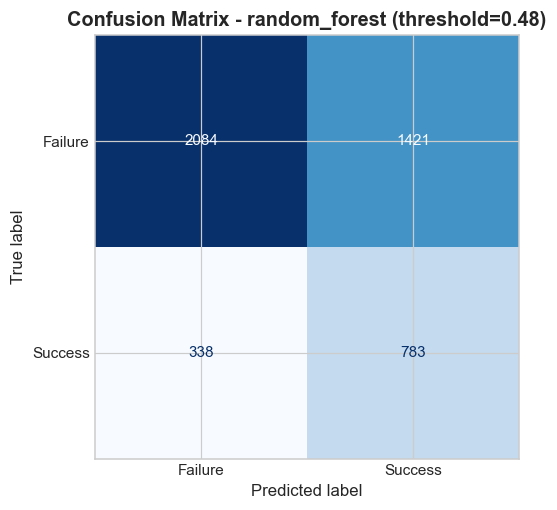

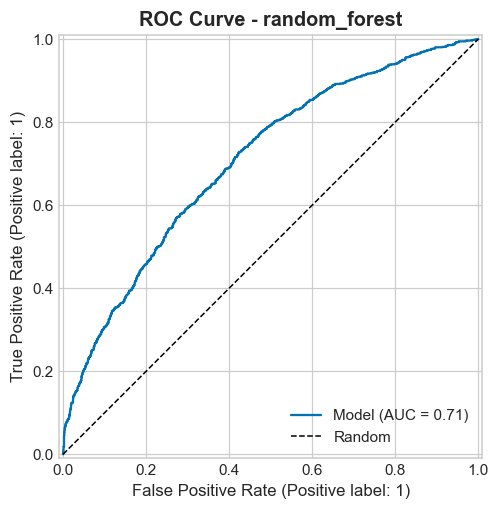

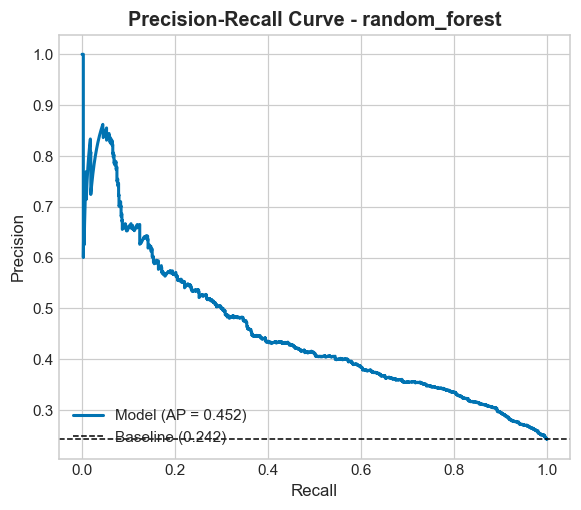

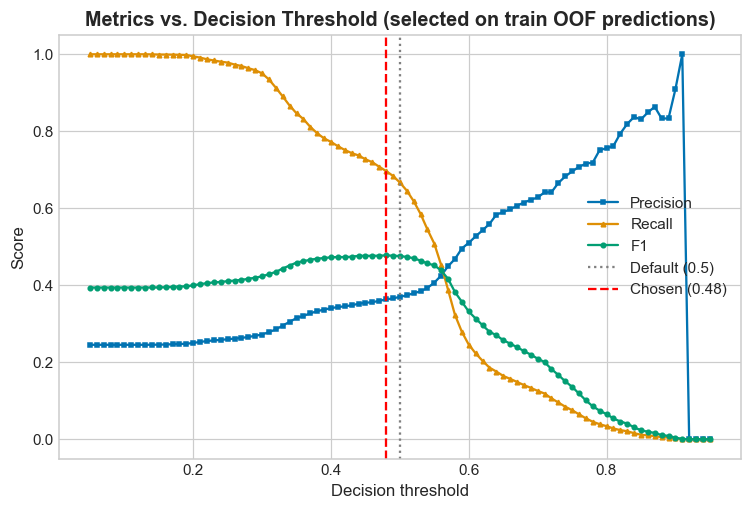

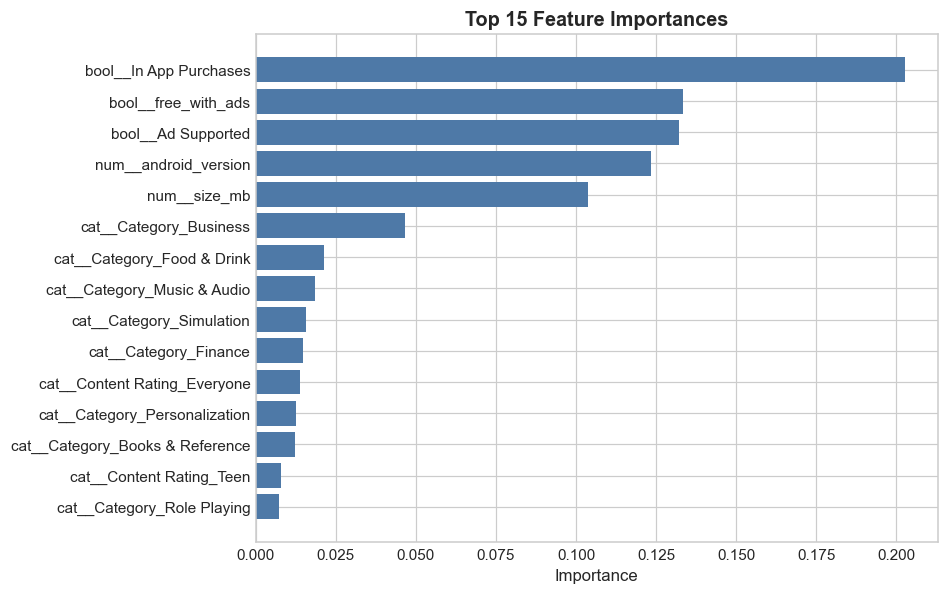

In [7]:
from pathlib import Path

from playstore.config import DEFAULT_ARTIFACTS_DIR, DEFAULT_FIGURES_DIR, TrainConfig
from playstore.train import main as run_training

# Writes to artifacts/demo/ and reports/figures/demo/ -- NOT the paths the
# README's figures/metrics point at -- so re-running this notebook can never
# silently overwrite the full run's reported results with this tiny demo's.
demo_config = TrainConfig(
    sample_frac=0.01,
    tuning_iterations=3,
    cv_folds=2,
    artifacts_dir=Path(DEFAULT_ARTIFACTS_DIR) / "demo",
    figures_dir=Path(DEFAULT_FIGURES_DIR) / "demo",
)
demo_results = run_training(demo_config)

print("Best model:", demo_results["best_model"])
print("Chosen threshold:", demo_results["chosen_threshold"])
print("Test metrics @ chosen threshold:", demo_results["test_metrics_chosen_threshold"])

## 5. Where to go next

* `src/playstore/train.py` -- the full, tested pipeline (cross-validation,
  tuning, leakage-safe threshold selection, artifact saving).
* `tests/` -- unit tests for the label logic and feature transformers, plus
  an end-to-end smoke test.
* `README.md` -- methodology, latest results, and known limitations.
